## Disease Prediction Using Machine Learning (Enhanced Version)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
from imblearn.over_sampling import RandomOverSampler
%matplotlib inline

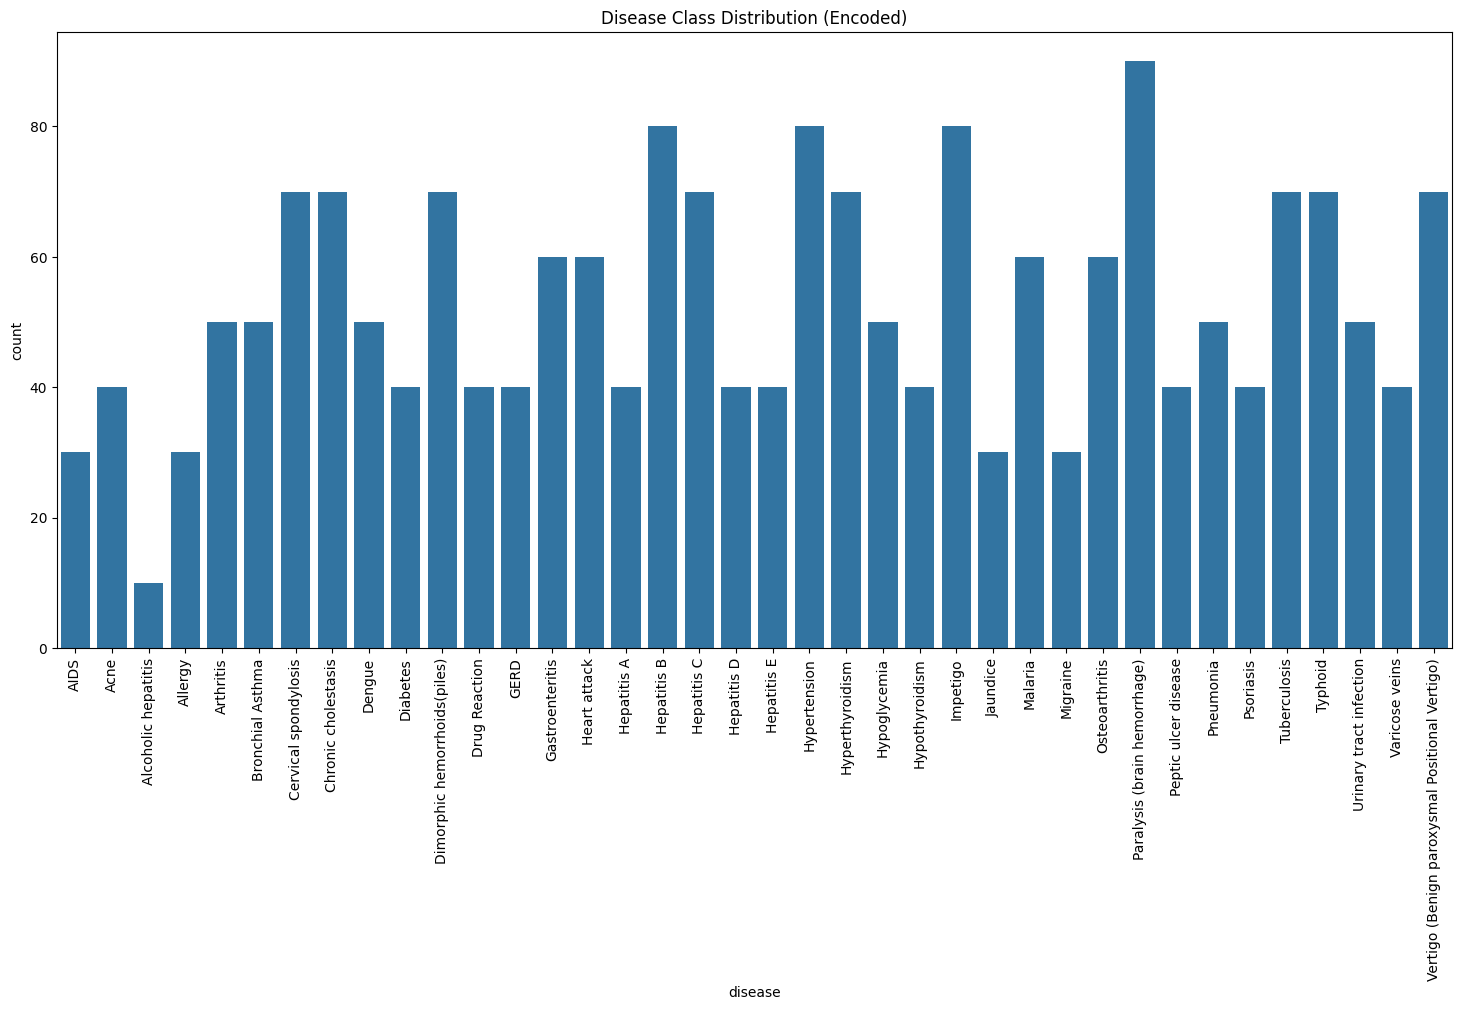

In [12]:
data = pd.read_csv('improved_disease_dataset.csv')

# Encoding the target
encoder = LabelEncoder()
data["disease"] = encoder.fit_transform(data["disease"])

X = data.iloc[:, :-1].fillna(0)
y = data.iloc[:, -1]

# Visualization of Initial Distribution
plt.figure(figsize=(18, 8))
sns.countplot(x=data["disease"])
plt.title("Disease Class Distribution (Encoded)")
plt.xticks(ticks=range(len(encoder.classes_)), labels=encoder.classes_, rotation=90)
plt.show()

# Resampling to handle imbalance
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

In [13]:
# Define base models
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
svm_model = SVC(kernel='rbf', probability=True, C=1.0, random_state=42)

models = {
    "Random Forest": rf_model,
    "SVM": svm_model
}

if XGBClassifier:
    xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
    models["XGBoost"] = xgb_model

# Create a Voting Ensemble for better accuracy
ensemble = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting='soft'
)
models["Ensemble Model"] = ensemble

# Cross-Validation
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for model_name, model in models.items():
    try:
        scores = cross_val_score(model, X_resampled, y_resampled, cv=stratified_kfold, scoring='accuracy', n_jobs=-1)
        print(f"{model_name} Mean Accuracy: {scores.mean():.4f}")
    except Exception as e:
        print(f"Error evaluating {model_name}: {e}")

Random Forest Mean Accuracy: 0.5453
SVM Mean Accuracy: 0.5000
XGBoost Mean Accuracy: 0.5266
Ensemble Model Mean Accuracy: 0.5471


c:\Users\VIVOBBOK 16\.conda\envs\gesturecontrol\lib\site-packages\xgboost\training.py:200: UserWarning: [17:02:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Final Ensemble Accuracy (Hold-out): 0.543859649122807

Classification Report:
                                                 precision    recall  f1-score   support

                                          AIDS       0.67      0.89      0.76        18
                                          Acne       0.55      0.85      0.67        13
                           Alcoholic hepatitis       0.67      0.83      0.74        12
                                       Allergy       0.53      0.53      0.53        17
                                     Arthritis       0.40      0.40      0.40        15
                              Bronchial Asthma       0.38      0.29      0.33        17
                          Cervical spondylosis       0.70      0.50      0.58        14
                           Chronic cholestasis       0.58      0.65      0.61        17
                                        Dengue       0.47      0.42      0.44        19
                                      D

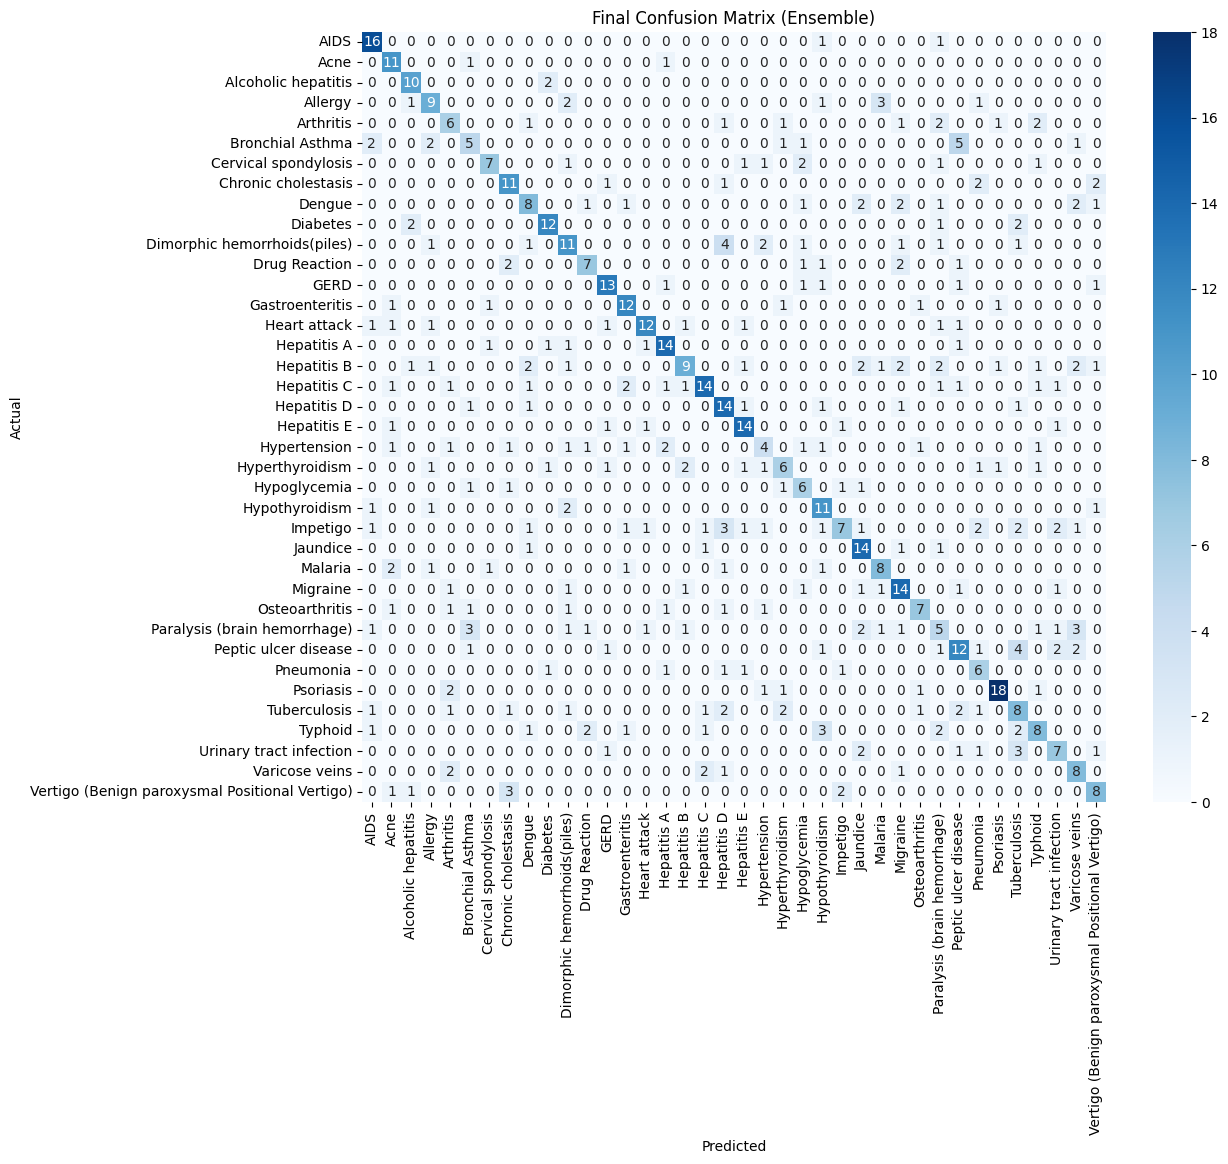

In [14]:
# Training the final Ensemble model
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

final_model = models["Ensemble Model"]
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print("\nFinal Ensemble Accuracy (Hold-out):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_, cmap='Blues')
plt.title("Final Confusion Matrix (Ensemble)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()